1. Motor representation of a pose
2. Continous in time

Question: Lie group or Lie algebra?

In [6]:
from kingdon import Algebra
import numpy as np
alg = Algebra(3, 0, 1)
locals().update(alg.blades)

def bone_pairs(points):
    return [[points[parent], points[child]] for child, parent in kinematic_child_parent]

def xyz_to_point(v):
    x,y,z = v
    return (e0 + x * e1 + y * e2 + z * e3).dual()

def trp(p0, p1):
    """ Translate from p0 to p1. """
    line = p0 & p1
    return ((0.5 * e0) ^ (line | e123)).exp()

smpl = np.load('../serialized/model.npz')
kinematic_child_parent = list(enumerate(smpl['kintree_table'][0][1:22], start=1))
bone_vertices = smpl['J'][:22]
bone_points = [xyz_to_point(v) for v in bone_vertices]

alg.graph(
    0x557722, *bone_pairs(bone_points),
    grid=True, labels=True, pointRadius=0.2
)

In [8]:
motion = np.load('../serialized/05_07_poses.npz')
frame = 0
ex_fps = 20
fps = motion['mocap_framerate']
down_sample = int(fps / ex_fps)
# frame_number = bdata['trans'].shape[0]
#         print(list(bdata.keys()))

station_joint_translation = [1 + 0*e01 + 0*e02 + 0*e03]
for child, parent in kinematic_child_parent:
    if child >= 22:
        break
    station_joint_translation.append(trp(bone_points[parent], bone_points[child]))

def axis_angle_to_rotor(axis_angle, bone_index):
    theta = np.linalg.norm(axis_angle)
    B = xyz_to_point(axis_angle) & e123
    rotator = np.cos(theta/2) + 0.5*np.sinc(0.5 * theta / np.pi) * B
    translator = station_joint_translation[bone_index+1]
    return translator * rotator

# motion = np.load('motions/wave_right03_poses.npz')
root_orient = motion['poses'][::down_sample, :3] # 1 root joint
pose_body = motion['poses'][::down_sample, 3:66] # 21 child joints
root_trans = motion['trans'][::down_sample,...]

axis_angles = pose_body[frame].reshape(-1, 3)

In [9]:
# diffusion process as the linear blending of the axis_angles
# t between 0 and 1
t = 1

median = np.median(pose_body, axis=0)
std = np.std(pose_body, axis=0)
random_axis_angles = np.random.normal(loc=median, scale=3*std).reshape(-1, 3)
blend_angles = [t*a0 + (1-t)*ar for a0, ar in zip(axis_angles, random_axis_angles)]
# blend_rotors = [t*m0 + (1-t)*mr for m0, mr in zip(rotors, random_rotors)]
blend_rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(blend_angles)]
full_motors = blend_rotors.copy()
for child, parent in kinematic_child_parent:
    if child >= 22:
        break
    if parent > 0:
        full_motors[child] = full_motors[parent] * full_motors[child]

moved_points = [(r)>> e123 for r in full_motors]

alg.graph(
    0x555555, *bone_pairs(moved_points),
    grid=True, labels=True, pointRadius=0.5
)

In [10]:
# swap left/right
t = 1

median = np.median(pose_body, axis=0)
std = np.std(pose_body, axis=0)
random_axis_angles = np.random.normal(loc=median, scale=3*std).reshape(-1, 3)
blend_angles = [t*a0 + (1-t)*ar for a0, ar in zip(axis_angles, random_axis_angles)]
# blend_rotors = [t*m0 + (1-t)*mr for m0, mr in zip(rotors, random_rotors)]
blend_rotors = [1+0*e12] + [e1>>axis_angle_to_rotor(a, i) for i, a in enumerate(blend_angles)]
full_motors = blend_rotors.copy()
for child, parent in kinematic_child_parent:
    if child >= 22:
        break
    if parent > 0:
        full_motors[child] = full_motors[parent] * full_motors[child]

moved_points = [(r)>> e123 for r in full_motors]

alg.graph(
    0x555555, *bone_pairs(moved_points),
    grid=True, labels=True, pointRadius=0.5
)

In [5]:
# quaternion/motor is a double cover of motion
# Chosen to be continuous in time

def expmap_to_quaternion(e):
    """
    Convert axis-angle rotations (aka exponential maps) to quaternions.
    Stable formula from "Practical Parameterization of Rotations Using the Exponential Map".
    Expects a tensor of shape (*, 3), where * denotes any number of dimensions.
    Returns a tensor of shape (*, 4).
    """
    assert e.shape[-1] == 3

    original_shape = list(e.shape)
    original_shape[-1] = 4
    e = e.reshape(-1, 3)

    theta = np.linalg.norm(e, axis=1).reshape(-1, 1)
    w = np.cos(0.5 * theta).reshape(-1, 1)
    xyz = 0.5 * np.sinc(0.5 * theta / np.pi) * e
    return np.concatenate((w, xyz), axis=1).reshape(original_shape)

def qfix(q):
    """
    Enforce quaternion continuity across the time dimension by selecting
    the representation (q or -q) with minimal distance (or, equivalently, maximal dot product)
    between two consecutive frames.

    Expects a tensor of shape (L, J, 4), where L is the sequence length and J is the number of joints.
    Returns a tensor of the same shape.
    """
    # assert len(q.shape) == 3
    assert q.shape[-1] == 4
    dot_products = np.sum(q[1:] * q[:-1], axis=1)
    mask = dot_products < 0
    num_flip = np.sum(mask)
    if num_flip:
        print(f'with {num_flip} sign flips')
        result = q.copy()
        mask = (np.cumsum(mask, axis=0) % 2).astype(bool)
        result[1:][mask] *= -1
        return result
    return q

quat_root_orient = expmap_to_quaternion(root_orient)
quat_root_orient = qfix(quat_root_orient)

In [6]:
def root_to_motor(orient, trans):
    theta = np.linalg.norm(orient)
    B = xyz_to_point(orient) & e123
    rotator = np.cos(theta/2) + 0.5*np.sinc(0.5 * theta / np.pi) * B
    translator = trp(e123, xyz_to_point(trans))
    return translator * rotator

def root_to_rot_motor(orient, trans):
    theta = np.linalg.norm(orient)
    B = xyz_to_point(orient) & e123
    rotator = np.cos(theta/2) + 0.5*np.sinc(0.5 * theta / np.pi) * B
    return rotator

root_motors = [root_to_motor(o,t) for o, t in zip(root_orient, root_trans)]
root_rot_motors = [root_to_rot_motor(o,t) for o, t in zip(root_orient, root_trans)]
root_body_motors = [~r * root_motors[0] for r in root_motors]
root_body_rot_motors = [~root_rot_motors[0] * r for r in root_rot_motors]

In [7]:
import time

frame = 0
floors = [(~r)>>e3 for r in root_motors]
def animation():
    global start
    frame = int(((time.time() - start) * 10 //1 ) % len(root_body_motors))
    axis_angles = pose_body[frame].reshape(-1, 3)
    rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(axis_angles)]
    full_motors = rotors.copy()
    for child, parent in kinematic_child_parent:
        if child >= 22:
            break
        if parent > 0:
            # Note that the child operators act before parents on the origin
            full_motors[child] = full_motors[parent] * full_motors[child]
    moved_points = [(r)>> e123 for r in full_motors]
    
    trajec = [~r >> e123 for r in  root_body_motors[:frame]]
    trajec_o = [r >> e123 for r in  root_body_motors[:frame]]
    return [f"{frame}", floors[frame], *trajec, 0x555555, *trajec_o, *bone_pairs(~root_body_motors[frame] >> moved_points), 0x337755, *bone_pairs(moved_points),]
start = time.time()
alg.graph(
    animation,
    grid=True, labels=True, pointRadius=0.2, animate=True
)

GraphWidget(cayley=[['1', 'e0', 'e1', 'e2', 'e3', 'e01', 'e02', 'e03', 'e12', 'e13', 'e23', 'e012', 'e013', 'e…

In [9]:
frame = 0
axis_angles = pose_body[frame].reshape(-1, 3)
rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(axis_angles)]
full_motors = rotors.copy()
for child, parent in kinematic_child_parent:
    if child >= 22:
        break
    if parent > 0:
        # Note that the child operators act before parents on the origin
        full_motors[child] = full_motors[parent] * full_motors[child]
chained = [~root_body_motors[frame] * r for r in full_motors]
chained_points = [(r)>> e123 for r in chained]
alg.graph(
    0x555555, *bone_pairs(chained_points),
    grid=True, labels=True, pointRadius=0.5
)


GraphWidget(cayley=[['1', 'e0', 'e1', 'e2', 'e3', 'e01', 'e02', 'e03', 'e12', 'e13', 'e23', 'e012', 'e013', 'e…

In [10]:
# rotation between 2 vectors
from kingdon import MultiVector
def normsq(A: MultiVector):
    return abs(A.sp(A.reverse()).e)

def norm(A):
    return np.sqrt(normsq(A))

def normalize(A, tol=1e-8):
    n = norm(A)
    assert (n > tol).all(), f"zero norm {n[n <= tol]}"
    return A / n

def rotor_between(v0, v1):
    return normalize(1 + normalize(v1) * normalize(v0))

r = rotor_between(normalize(e1+ e2 +3*e3), normalize(2*e1 + e2))
r >> normalize(e1+ e2 +3*e3), normalize(2*e1 + e2), r


(0.894 𝐞₁ + 0.447 𝐞₂ + -2.22e-16 𝐞₃,
 0.894 𝐞₁ + 0.447 𝐞₂,
 0.838 + 0.0805 𝐞₁₂ + 0.483 𝐞₁₃ + 0.241 𝐞₂₃)

In [21]:
# swapping left/right

import time

frame = 0

def animation():
    global start
    frame = int(((time.time() - start) * 10 //1 ) % len(root_body_motors))
    axis_angles = pose_body[frame].reshape(-1, 3)
    rotors = [1+0*e12] + [e1>>axis_angle_to_rotor(a, i) for i, a in enumerate(axis_angles)]
    full_motors = rotors.copy()
    for child, parent in kinematic_child_parent:
        if child >= 22:
            break
        if parent > 0:
            # Note that the child operators act before parents on the origin
            full_motors[child] = full_motors[parent] * full_motors[child]
    moved_points = [(r)>> e123 for r in full_motors]
    return [f"{frame}", 0x555555, *bone_pairs((e1>>~root_body_motors[frame]) >> moved_points), 0x337755, *bone_pairs(moved_points),]
start = time.time()
alg.graph(
    animation,
    grid=True, labels=True, pointRadius=0.2, animate=True
)

GraphWidget(cayley=[['1', 'e0', 'e1', 'e2', 'e3', 'e01', 'e02', 'e03', 'e12', 'e13', 'e23', 'e012', 'e013', 'e…

In [ ]:
# swapping left/right

import time

frame = 0

def animation():
    global start
    frame = int(((time.time() - start) * 10 //1 ) % len(root_body_motors))
    axis_angles = pose_body[frame].reshape(-1, 3)
    rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(axis_angles)]
    full_motors = rotors.copy()
    for child, parent in kinematic_child_parent:
        if child >= 22:
            break
        if parent > 0:
            # Note that the child operators act before parents on the origin
            full_motors[child] = full_motors[parent] * full_motors[child]
    moved_points = [(e1>>r)>> e123 for r in full_motors]
    return [f"{frame}", 0x555555, *bone_pairs((e1>>~root_body_motors[frame]) >> moved_points), 0x337755, *bone_pairs(moved_points),]
start = time.time()
alg.graph(
    animation,
    grid=True, labels=True, pointRadius=0.2, animate=True
)

GraphWidget(cayley=[['1', 'e0', 'e1', 'e2', 'e3', 'e01', 'e02', 'e03', 'e12', 'e13', 'e23', 'e012', 'e013', 'e…

In [ ]:
import time

frame = 0

def animation():
    global start
    frame = int(((time.time() - start) * 10 //1 ) % len(root_body_motors))
    axis_angles = pose_body[frame].reshape(-1, 3)
    rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(axis_angles)]
    full_motors = rotors.copy()
    for child, parent in kinematic_child_parent:
        if child >= 22:
            break
        if parent > 0:
            # Note that the child operators act before parents on the origin
            full_motors[child] = full_motors[parent] * full_motors[child]
    chained_points = [(r)>> e123 for r in full_motors]
    moved_points = ~root_body_motors[frame] >> chained_points
    floor = ~root_motors[0]>>e3
    return [f"{frame}", 0x555555, *bone_pairs(moved_points), 0x337755, *bone_pairs(moved_points), floor, f"{min((floor & p).e for p in moved_points)}"]
start = time.time()
alg.graph(
    animation,
    grid=True, labels=True, pointRadius=0.2, animate=True
)

GraphWidget(cayley=[['1', 'e0', 'e1', 'e2', 'e3', 'e01', 'e02', 'e03', 'e12', 'e13', 'e23', 'e012', 'e013', 'e…

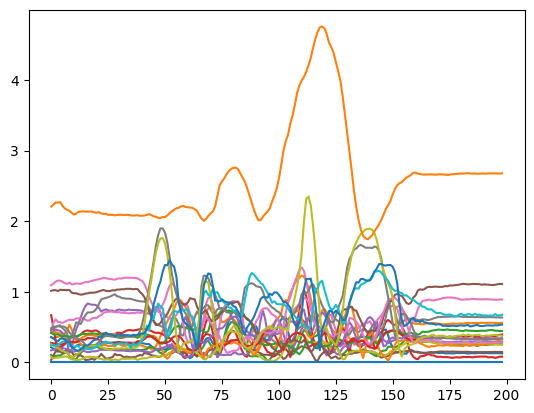

In [15]:
# Here I plot the "axis-angles"
# Compare with above animation, anything strange?
# Does it looks familiar?
# It oscillate in a range of size pi

import matplotlib.pyplot as plt
plt.plot(np.linalg.norm(pose_body.reshape(len(pose_body), -1, 3), axis=2))
plt.plot(np.linalg.norm(root_orient, axis=1))

In [16]:
frame = 0
thetas = np.linalg.norm(root_orient, axis=1)
root_axis = [xyz_to_point(0.2* r)/t for r,t in zip(root_orient, thetas)]

def animation():
    global start
    frame = int(((time.time() - start) * 10 //1 ) % len(root_body_motors))
    axis_angles = pose_body[frame].reshape(-1, 3)
    rotors = [1+0*e12] + [axis_angle_to_rotor(a, i) for i, a in enumerate(axis_angles)]
    full_motors = rotors.copy()
    for child, parent in kinematic_child_parent:
        if child >= 22:
            break
        if parent > 0:
            # Note that the child operators act before parents on the origin
            full_motors[child] = full_motors[parent] * full_motors[child]
    moved_points = [(r)>> e123 for r in full_motors]
    color = 0x555555 if ((frame > 713) and (frame < 835)) else 0x337755
    ref = xyz_to_point(0.5*np.ones(3))
    return [f"{frame}", color, *bone_pairs(root_rot_motors[frame] >> moved_points), root_rot_motors[frame] >> [e123, e123 + e012, e123 + e023], root_axis[frame], [ref, ref + 0.5*thetas[frame]*e023]]
start = time.time()
alg.graph(
    animation,
    grid=True, labels=True, pointRadius=0.5, animate=True
)

GraphWidget(cayley=[['1', 'e0', 'e1', 'e2', 'e3', 'e01', 'e02', 'e03', 'e12', 'e13', 'e23', 'e012', 'e013', 'e…

In [17]:
# The original angle starts from 0 to 4 pi
# But exp -> log, it oscillates between 0 and pi

from kingdon import MultiVector

def simple_rotor_log(R: MultiVector, tol=1e-8):
    blade = R.grade(2)
    if abs(R.e - 1) < tol:
        return blade
    signature = (blade**2).e
    norm = np.sqrt(abs(signature))
    if signature > tol:
        return np.arccosh(R.e) * blade/norm
    if signature < -tol:
        return np.arccos(R.e) * blade/norm
for t in np.linspace(0, 4*np.pi, 13):
    B = (t-1e-2) * e12 
    R = B.exp()
    B0 = simple_rotor_log(R)
    # B1 = simple_rotor_log(-R)
    print(B, '->', B0)

-0.01 𝐞₁₂ -> -0.01 𝐞₁₂
1.04 𝐞₁₂ -> 1.04 𝐞₁₂
2.08 𝐞₁₂ -> 2.08 𝐞₁₂
3.13 𝐞₁₂ -> 3.13 𝐞₁₂
4.18 𝐞₁₂ -> -2.1 𝐞₁₂
5.23 𝐞₁₂ -> -1.06 𝐞₁₂
6.27 𝐞₁₂ -> -0.01 𝐞₁₂
7.32 𝐞₁₂ -> 1.04 𝐞₁₂
8.37 𝐞₁₂ -> 2.08 𝐞₁₂
9.41 𝐞₁₂ -> 3.13 𝐞₁₂
10.5 𝐞₁₂ -> -2.1 𝐞₁₂
11.5 𝐞₁₂ -> -1.06 𝐞₁₂
12.6 𝐞₁₂ -> -0.01 𝐞₁₂


In [18]:
# Lie algbra computation
B1 = e12 + e23
B2 = e23
R1 = B1.exp()
R2 = B2.exp()
(
    R1, R2, 
    R1 * ~R2, 
    (B1 - B2).exp(), 
    (B1 - B2 - B1.cp(-B2)).exp()
    )

(0.156 + 0.698 𝐞₁₂ + 0.698 𝐞₂₃,
 0.54 + 0.841 𝐞₂₃,
 0.672 + 0.377 𝐞₁₂ + -0.588 𝐞₁₃ + 0.246 𝐞₂₃,
 0.54 + 0.841 𝐞₁₂,
 0.156 + 0.698 𝐞₁₂ + 0.698 𝐞₁₃)

In [19]:
B3 = e01
R3 = B3.exp()
(
    R2, R3,
    B2.cp(B3),
    R2 * R3,
    R3 * R2,
)

(0.54 + 0.841 𝐞₂₃,
 1 + 1 𝐞₀₁,
 0,
 0.54 + 0.54 𝐞₀₁ + 0.841 𝐞₂₃ + 0.841 𝐞₀₁₂₃,
 0.54 + 0.54 𝐞₀₁ + 0.841 𝐞₂₃ + 0.841 𝐞₀₁₂₃)

In [20]:
# Blending of R1 and R2
diff_rotor = ~R1*R2
diff_bivec = simple_rotor_log(diff_rotor)
diff_bivec

-0.425 𝐞₁₂ + -0.662 𝐞₁₃ + -0.277 𝐞₂₃

In [21]:
t = 0.8
R1, R2, R1 * (t*diff_bivec).exp()

(0.156 + 0.698 𝐞₁₂ + 0.698 𝐞₂₃, 0.54 + 0.841 𝐞₂₃, 0.486 + 0.157 𝐞₁₂ + 0.86 𝐞₂₃)

In [22]:
# linear blending of the lie algebra
b1 = (1-t)*B1
b2 = t*B2
(b1 + b2).exp(), (b1 + b2 + 0.5*b1.cp(b2)).exp()

(0.524 + 0.167 𝐞₁₂ + 0.835 𝐞₂₃, 0.521 + 0.167 𝐞₁₂ + 0.0668 𝐞₁₃ + 0.835 𝐞₂₃)

In [23]:
# dual quaternion blending
R = ((1 - t)*R1 + t*R2)
R, R.normalized()

(0.463 + 0.14 𝐞₁₂ + 0.813 𝐞₂₃, 0.49 + 0.148 𝐞₁₂ + 0.859 𝐞₂₃)

In [35]:
# What's the problem?
# We should view a motor as accumulated by time.
# The difference between two frames, reflects the orientation of a motion

l = 125
r = 128
inst_root_rotors = [r1 * ~r0 for r1, r0 in zip(root_body_rot_motors[1:], root_body_rot_motors[:-1])]
r1 = root_body_rot_motors[l]
r2 = root_body_rot_motors[r]
r3 = inst_root_rotors[l]
r4 = inst_root_rotors[r]

v1, v2, v3, v4 = [simple_rotor_log(r).values() for r in [r1,r2,r3,r4]]
np.dot(v1, v2), np.dot(v3, v4)

(np.float64(-8.142282371197993), np.float64(0.030483333524300837))

In [37]:
# The orientation of the rotation is not always aligned

l = 108
r = 125
inst_root_rotors = [r1 * ~r0 for r1, r0 in zip(root_body_rot_motors[1:], root_body_rot_motors[:-1])]
r1 = root_body_rot_motors[l]
r2 = root_body_rot_motors[r]
r3 = inst_root_rotors[l]
r4 = inst_root_rotors[r]

v1, v2, v3, v4 = [simple_rotor_log(r).values() for r in [r1,r2,r3,r4]]
np.dot(v1, v2), np.dot(v3, v4)

(np.float64(2.145213014847475), np.float64(0.01271756816478829))

In [38]:
# Or the original angle axis

l = 125
r = 128
inst_root_rotors = [r1 * ~r0 for r1, r0 in zip(root_body_rot_motors[1:], root_body_rot_motors[:-1])]
r1 = root_body_rot_motors[l]
r2 = root_body_rot_motors[r]
r3 = inst_root_rotors[l]
r4 = inst_root_rotors[r]

v1, v2, v3, v4 = [simple_rotor_log(r).values() for r in [r1,r2,r3,r4]]
np.dot(root_orient[l], root_orient[r]), np.dot(v3, v4)

(np.float64(14.085525508644245), np.float64(0.030483333524300837))

In [39]:
l = 106
r = 125
inst_root_rotors = [r1 * ~r0 for r1, r0 in zip(root_body_rot_motors[1:], root_body_rot_motors[:-1])]
r1 = root_body_rot_motors[l]
r2 = root_body_rot_motors[r]
r3 = inst_root_rotors[l]
r4 = inst_root_rotors[r]

v1, v2, v3, v4 = [simple_rotor_log(r).values() for r in [r1,r2,r3,r4]]
np.dot(root_orient[l], root_orient[r]), np.dot(v3, v4)

(np.float64(-12.327158172661267), np.float64(0.011418552937603271))

### Recap
1. The inst difference rotor reflects the orientation of the motion
2. We can book-keep the global motion by accumulates the inst lie algebras. e.g.
```-0.01 𝐞₁₂ -> -0.01 𝐞₁₂
1.04 𝐞₁₂ -> 1.04 𝐞₁₂
2.08 𝐞₁₂ -> 2.08 𝐞₁₂
3.13 𝐞₁₂ -> 3.13 𝐞₁₂
4.18 𝐞₁₂ -> -2.1 𝐞₁₂
5.23 𝐞₁₂ -> -1.06 𝐞₁₂
6.27 𝐞₁₂ -> -0.01 𝐞₁₂
7.32 𝐞₁₂ -> 1.04 𝐞₁₂
8.37 𝐞₁₂ -> 2.08 𝐞₁₂
9.41 𝐞₁₂ -> 3.13 𝐞₁₂
10.5 𝐞₁₂ -> -2.1 𝐞₁₂
11.5 𝐞₁₂ -> -1.06 𝐞₁₂
12.6 𝐞₁₂ -> -0.01 𝐞₁₂
```
for pga motors and its bivectos we can iteratively compute
$$ b_0 + b_1 - [b_0, b_1]$$

But do we need a accumulated motion?

This approach, known as delta-based modeling, is preferred because it forces the model to learn the fundamental dynamics of motion rather than memorizing absolute poses.

In [20]:
inst_bivectors = [simple_rotor_log(r) for r in inst_root_rotors]
inst_bivectors[:5]

[-0.00201 𝐞₁₂ + 0.00295 𝐞₁₃ + 0.00368 𝐞₂₃,
 -4.16e-05 𝐞₁₂ + 0.00624 𝐞₁₃ + -0.00317 𝐞₂₃,
 -0.00581 𝐞₁₂ + -0.00485 𝐞₁₃ + 0.00641 𝐞₂₃,
 0.00262 𝐞₁₂ + 0.0125 𝐞₁₃ + 0.000978 𝐞₂₃,
 0.00196 𝐞₁₂ + 0.00938 𝐞₁₃ + 0.00354 𝐞₂₃]

In [21]:
lie_brackets = [b1.cp(b2) for b1, b2 in zip(inst_bivectors[:-1], inst_bivectors[1:])]
np.mean([l.values() for l in lie_brackets]), np.std([l.values() for l in lie_brackets])

(np.float64(2.0035667170317112e-07), np.float64(3.146782486540489e-05))

In [23]:
b_vecs = [b.values() for b in inst_bivectors]
mean = np.mean(b_vecs, axis=0)
std = np.std(b_vecs, axis=0)
random_b_vecs = np.random.normal(loc=mean, scale=std).reshape(-1, 3)

In [25]:
def xyz_to_bivec(v):
    x, y, z = v
    return x*e12+y*e13+z*e23

random_bivectors = [xyz_to_bivec(v) for v in random_b_vecs]
lie_brackets = [b1.cp(b2) for b1, b2 in zip(random_bivectors, inst_bivectors)]
np.mean([l.values() for l in lie_brackets]), np.std([l.values() for l in lie_brackets])

(np.float64(5.971011511821961e-06), np.float64(4.817082019114009e-06))

## Lie Group or Lie Algebra
### Lie Algebra (bivectors)

The Lie algebra is a vector space that is tangent to the Lie group at the identity. It is a flat, unconstrained space where elements can be added and scaled linearly.

1. Simple Optimization: Because the Lie algebra is a flat vector space, you can use standard, off-the-shelf optimization algorithms like gradient descent without any modifications. There are no constraints to enforce, so you don't need complex projection or re-normalization steps.

2. Intuitive Gradients: Gradients computed in the Lie algebra are simple vectors that directly correspond to the direction of change. This makes them easy to interpret and use for learning.

### Lie Group (motors)

The Lie group is a curved manifold. The group elements (e.g., rotations and translations) must satisfy complex non-linear constraints (e.g., a quaternion must have unit norm).

1. Complex Optimization: Optimizing directly on a Lie group is challenging. You can't simply add gradients to a group element and expect the result to stay on the manifold. This requires special "manifold optimization" techniques or projections, which are computationally expensive and difficult to implement.

2. Non-linear Gradients: Gradients are not simple vectors but must be carefully handled to respect the manifold's curvature.

### Compare with 

1. Standard affine NN: outputs arbitrary matrices 
→ has no bias toward geometry.

2. Lie algebra NN: outputs elements of aff(n) and exponentiates 
→ enforces group structure (composition of transformations stays in the group).

3. GA-based NN (e.g. R$_{3,3}$): outputs bivectors
→ enforces geometric structure:
Rotations, translations, scalings are disentangled by construction.
Composition is automatic via geometric product.
Features like “line incidence” or “point in plane” are baked into the algebra.

This is a better inductive bias because the model doesn’t need to rediscover geometry; it starts with the right structure.
<!-- 
This is a general view of how GA neural network can enhance from a Lie algebra neural network. Both Lie alg and GA have can enforce some geometric equivariance or group structure. But GA has more structure.  the constraints  -->

## Positional Encoding

1. tree structure
2. 5 end points and 1 single root


In [ ]:
from collections import defaultdict
parents = {}
children = defaultdict(list)
for child, parent in kinematic_child_parent:
    parents[child] = int(parent)
    children[int(parent)].append(child)
children

defaultdict(list,
            {0: [1, 2, 3],
             1: [4],
             2: [5],
             3: [6],
             4: [7],
             5: [8],
             6: [9],
             7: [10],
             8: [11],
             9: [12, 13, 14],
             12: [15],
             13: [16],
             14: [17],
             16: [18],
             17: [19],
             18: [20],
             19: [21]})

In [35]:
def dfs(node, chain):
    chain.append(node)
    if node not in children:  # leaf
        chains.append(chain.copy())
    else:
        for c in children[node]:
            dfs(c, chain)
    chain.pop()
chains = []
dfs(0, [])
chains


[[0, 1, 4, 7, 10],
 [0, 2, 5, 8, 11],
 [0, 3, 6, 9, 12, 15],
 [0, 3, 6, 9, 13, 16, 18, 20],
 [0, 3, 6, 9, 14, 17, 19, 21]]

In [50]:
positional_encodings = []
for joint in range(1, 22):
    pe = []
    for c in chains:
        if joint in c:
            pe.append(c.index(joint))
            break
    for c in chains:
        if joint in c:
            pe.append(len(c) - pe[0])
        else:
            pe.append(len(c) + pe[0])
    positional_encodings.append(pe)
positional_encodings

[[1, 4, 6, 7, 9, 9],
 [1, 6, 4, 7, 9, 9],
 [1, 6, 6, 5, 7, 7],
 [2, 3, 7, 8, 10, 10],
 [2, 7, 3, 8, 10, 10],
 [2, 7, 7, 4, 6, 6],
 [3, 2, 8, 9, 11, 11],
 [3, 8, 2, 9, 11, 11],
 [3, 8, 8, 3, 5, 5],
 [4, 1, 9, 10, 12, 12],
 [4, 9, 1, 10, 12, 12],
 [4, 9, 9, 2, 12, 12],
 [4, 9, 9, 10, 4, 12],
 [4, 9, 9, 10, 12, 4],
 [5, 10, 10, 1, 13, 13],
 [5, 10, 10, 11, 3, 13],
 [5, 10, 10, 11, 13, 3],
 [6, 11, 11, 12, 2, 14],
 [6, 11, 11, 12, 14, 2],
 [7, 12, 12, 13, 1, 15],
 [7, 12, 12, 13, 15, 1]]